# Improved ResNet for Time Series Classification
## Improving Wang, Yan & Oates (2016)

---

### Areas for improvement in the original ResNet reproduction

| # | Issues | Fix |
|---|-------|-----|
| 1 | **Conv2D on (T,1,1)** but paper describes 1D convolutions | Rewrite with Conv1D |
| 2 | **Three residual blocks hardcoded** (90+ lines copy-paste) | Parameterised function |
| 3 | **Extra BatchNorm on input** — not in the paper | Removed |
| 4 | Code duplicated per dataset | Modular pipeline |
| 5 | Float batch_size, fragile label encoding | Integer `//`, LabelEncoder |
| 6 | Only `np.random.seed` | Seed all RNGs |
| 7 | No early stopping; min training loss selection | Early stopping on `val_loss` |
| 8 | `ReduceLROnPlateau` monitors training loss | Monitor `val_loss` |
| 9 | No GPU/MPS detection | Auto-detect + mixed precision |
| 10 | No dropout or regularisation (paper notes overfitting) | SpatialDropout + L2 |

In [11]:
pip install aeon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 17.1 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [1]:
import os
import random
import warnings
import time
import logging
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
logging.getLogger('tensorflow').setLevel(logging.ERROR)

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")

# GPU / MPS detection
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detected       : {[g.name for g in gpus]}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    try:
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print("Mixed precision    : enabled (float16)")
    except Exception:
        print("Mixed precision    : not available")
else:
    print("GPU detected       : None (using CPU)")

TensorFlow version : 2.19.0
NumPy version      : 2.0.2
GPU detected       : ['/physical_device:GPU:0']
Mixed precision    : enabled (float16)


In [2]:
# Comprehensive seed setting

# IMPROVEMENT: Original only called np.random.seed(813306).
# We seed Python, NumPy, and TensorFlow for reproducibility.


def set_all_seeds(seed: int = 813306) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['PYTHONHASHSEED'] = str(seed)

set_all_seeds(813306)

### Centralised Configuration

In [3]:
CONFIG = {
    'datasets': [
        'Adiac', 'GunPoint', 'Coffee', 'InlineSkate', 'MedicalImages',
    ],
    'nb_epochs': 1500,
    'batch_size_divisor': 10,
    'max_batch_size': 16,

    'adam_lr': 0.001,
    'adam_beta1': 0.9,
    'adam_beta2': 0.999,
    'adam_epsilon': 1e-8,

    'reduce_lr_monitor': 'val_loss',
    'reduce_lr_factor': 0.5,
    'reduce_lr_patience': 50,
    'reduce_lr_min_lr': 1e-4,

    'use_cosine_annealing': False,

    'seeds': [315, 7543, 813306],
    'jitter_sigma': 0.03,
    'output_dir': 'results',
}

PAPER_RESNET_ERRORS = {
    'Adiac': 0.174, 'GunPoint': 0.007, 'Coffee': 0.0,
    'InlineSkate': 0.635, 'MedicalImages': 0.228,
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)
print("Configuration loaded:")
for k, v in CONFIG.items():
    if k != 'output_dir':
        print(f"  {k:30s} = {v}")

Configuration loaded:
  datasets                       = ['Adiac', 'GunPoint', 'Coffee', 'InlineSkate', 'MedicalImages']
  nb_epochs                      = 1500
  batch_size_divisor             = 10
  max_batch_size                 = 16
  adam_lr                        = 0.001
  adam_beta1                     = 0.9
  adam_beta2                     = 0.999
  adam_epsilon                   = 1e-08
  reduce_lr_monitor              = val_loss
  reduce_lr_factor               = 0.5
  reduce_lr_patience             = 50
  reduce_lr_min_lr               = 0.0001
  use_cosine_annealing           = False
  seeds                          = [315, 7543, 813306]
  jitter_sigma                   = 0.03


### Data Loading & Preprocessing

In [4]:
# Robust UCR data loader

# IMPROVEMENT: Original readucr() assumed specific local paths
# and used inconsistent delimiters across cells.
# IMPROVEMENT: LabelEncoder replaces fragile min-max formula.


def load_ucr_dataset(name: str):
    try:
        from aeon.datasets import load_classification
        x_tr, y_tr = load_classification(name, split='train')
        x_te, y_te = load_classification(name, split='test')
        if x_tr.ndim == 3 and x_tr.shape[1] == 1:
            x_tr = x_tr.squeeze(axis=1)
            x_te = x_te.squeeze(axis=1)
        le = LabelEncoder()
        y_tr = le.fit_transform(y_tr).astype(np.int32)
        y_te = le.transform(y_te).astype(np.int32)
        print(f"    [aeon] Loaded '{name}'")
        return x_tr, y_tr, x_te, y_te
    except Exception as e:
        print(f"    [aeon] not available ({e}); trying local files...")

    for ext in ['', '.txt', '.tsv']:
        trn = os.path.join(name, f'{name}_TRAIN{ext}')
        tst = os.path.join(name, f'{name}_TEST{ext}')
        if os.path.exists(trn) and os.path.exists(tst):
            d_tr = np.loadtxt(trn, delimiter=',')
            d_te = np.loadtxt(tst, delimiter=',')
            x_tr, y_raw_tr = d_tr[:, 1:], d_tr[:, 0]
            x_te, y_raw_te = d_te[:, 1:], d_te[:, 0]
            le = LabelEncoder()
            y_tr = le.fit_transform(y_raw_tr).astype(np.int32)
            y_te = le.transform(y_raw_te).astype(np.int32)
            print(f"    [local] Loaded '{name}' from {trn}")
            return x_tr, y_tr, x_te, y_te

    raise FileNotFoundError(f"Cannot find '{name}'.")

In [5]:
# Z-normalisation (paper Section III-A)

# IMPROVEMENT: Guard against zero-variance and NaN values.

def z_normalise(x_train, x_test, per_feature=False):
    if per_feature:
        mean = x_train.mean(axis=0, keepdims=True)
        std  = x_train.std(axis=0, keepdims=True)
    else:
        mean = x_train.mean()
        std  = x_train.std()
    std = np.where(std == 0, 1.0, std)
    x_train_out = np.nan_to_num((x_train - mean) / std, nan=0.0)
    x_test_out  = np.nan_to_num((x_test  - mean) / std, nan=0.0)
    return x_train_out, x_test_out

In [17]:
# Preprocessing improvements

def augment_jitter(x, sigma=0.03, seed=None):
    """IMPROVEMENT: Add Gaussian noise for regularisation.
    The paper applies NO augmentation. Jitter is the simplest
    time series augmentation and helps on small datasets."""
    rng = np.random.RandomState(seed) if seed else np.random
    return x + rng.normal(0, sigma, x.shape)


def augment_scaling(x, sigma=0.1, seed=None):
    """IMPROVEMENT: Random per-sample amplitude scaling.
    Multiplies each sample by a factor drawn from N(1, sigma).
    Teaches the model invariance to signal amplitude changes."""
    rng = np.random.RandomState(seed) if seed else np.random
    factors = rng.normal(1.0, sigma, size=(x.shape[0], 1))
    return x * factors


def mixup_data(x, y, alpha=0.2, seed=None):
    """IMPROVEMENT: Mixup augmentation (Zhang et al., 2018).
    Creates virtual training samples by linearly interpolating
    between random pairs of samples and their labels.
    Strong regulariser proven effective on small datasets."""
    rng = np.random.RandomState(seed) if seed else np.random
    lam = rng.beta(alpha, alpha, size=(x.shape[0],))

    # Reshape lam to broadcast with x regardless of dimensionality
    # 2D x: (n, T) → lam becomes (n, 1)
    # 3D x: (n, T, 1) → lam becomes (n, 1, 1)
    lam_x = lam.reshape(-1, *([1] * (x.ndim - 1)))
    lam_y = lam.reshape(-1, 1)

    indices = rng.permutation(x.shape[0])
    x_mixed = lam_x * x + (1 - lam_x) * x[indices]
    y_mixed = lam_y * y + (1 - lam_y) * y[indices]
    return x_mixed, y_mixed


def get_class_weights(y_train):
    """IMPROVEMENT: Balanced class weights for imbalanced datasets.
    MedicalImages has 6-to-203 imbalance ratio."""
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    return dict(enumerate(weights))

In [7]:
# Load all datasets
data_store = {}

print("Loading datasets...\n")
for ds in CONFIG['datasets']:
    print(f"  --- {ds} ---")
    x_tr, y_tr, x_te, y_te = load_ucr_dataset(ds)
    x_tr, x_te = z_normalise(x_tr, x_te, per_feature=False)
    nb_classes = len(np.unique(y_tr))

    data_store[ds] = {
        'x_train': x_tr, 'y_train': y_tr,
        'x_test': x_te,  'y_test': y_te,
        'nb_classes': nb_classes,
    }

    counts = np.unique(y_tr, return_counts=True)[1]
    print(f"    Train shape : {x_tr.shape}  |  Test shape : {x_te.shape}")
    print(f"    Classes     : {nb_classes}  |  Samples per class: "
          f"min={counts.min()}, max={counts.max()}, mean={counts.mean():.1f}")

    imbalance = counts.max() / counts.min()
    if imbalance > 2.0:
        cw = get_class_weights(y_tr)
        print(f"    ⚠ Imbalance ratio: {imbalance:.1f}x — "
              f"class weights: [{min(cw.values()):.2f}, {max(cw.values()):.2f}]")
    print()

Loading datasets...

  --- Adiac ---
    [aeon] Loaded 'Adiac'
    Train shape : (390, 176)  |  Test shape : (391, 176)
    Classes     : 37  |  Samples per class: min=4, max=15, mean=10.5
    ⚠ Imbalance ratio: 3.8x — class weights: [0.70, 2.64]

  --- GunPoint ---
    [aeon] Loaded 'GunPoint'
    Train shape : (50, 150)  |  Test shape : (150, 150)
    Classes     : 2  |  Samples per class: min=24, max=26, mean=25.0

  --- Coffee ---
    [aeon] Loaded 'Coffee'
    Train shape : (28, 286)  |  Test shape : (28, 286)
    Classes     : 2  |  Samples per class: min=14, max=14, mean=14.0

  --- InlineSkate ---
    [aeon] Loaded 'InlineSkate'
    Train shape : (100, 1882)  |  Test shape : (550, 1882)
    Classes     : 7  |  Samples per class: min=9, max=18, mean=14.3

  --- MedicalImages ---
    [aeon] Loaded 'MedicalImages'
    Train shape : (381, 99)  |  Test shape : (760, 99)
    Classes     : 10  |  Samples per class: min=6, max=203, mean=38.1
    ⚠ Imbalance ratio: 33.8x — class weights

### ResNet Architecture

Paper (Section II-C, Figure 1c): 3 residual blocks (64, 128, 128 filters),
kernel sizes 8, 5, 3, shortcut connections, Global Average Pooling → Softmax.
Adam optimiser (lr=0.001).

**Original code issues:** Uses Conv2D on (T,1,1), 90+ lines of hardcoded blocks,
extra BatchNorm on input not in the paper.

In [8]:
# Original ResNet — faithful to paper with Conv1D

def _residual_block(x, n_filters, block_id):
    shortcut = x
    y = layers.Conv1D(n_filters, 8, padding='same', name=f'res{block_id}_conv1')(x)
    y = layers.BatchNormalization(name=f'res{block_id}_bn1')(y)
    y = layers.Activation('relu', name=f'res{block_id}_relu1')(y)

    y = layers.Conv1D(n_filters, 5, padding='same', name=f'res{block_id}_conv2')(y)
    y = layers.BatchNormalization(name=f'res{block_id}_bn2')(y)
    y = layers.Activation('relu', name=f'res{block_id}_relu2')(y)

    y = layers.Conv1D(n_filters, 3, padding='same', name=f'res{block_id}_conv3')(y)
    y = layers.BatchNormalization(name=f'res{block_id}_bn3')(y)

    if shortcut.shape[-1] != n_filters:
        shortcut = layers.Conv1D(n_filters, 1, padding='same',
                                 name=f'res{block_id}_shortcut')(shortcut)
        shortcut = layers.BatchNormalization(name=f'res{block_id}_shortcut_bn')(shortcut)

    out = layers.Add(name=f'res{block_id}_add')([y, shortcut])
    out = layers.Activation('relu', name=f'res{block_id}_relu_out')(out)
    return out

def build_resnet_original(input_length, nb_classes, learning_rate=0.001):
    inp = layers.Input(shape=(input_length, 1), name='input')
    x = _residual_block(inp, 64, 1)
    x = _residual_block(x, 128, 2)
    x = _residual_block(x, 128, 3)
    x = layers.GlobalAveragePooling1D(name='gap')(x)
    out = layers.Dense(nb_classes, activation='softmax', name='output')(x)
    model = keras.Model(inputs=inp, outputs=out, name='ResNet_Original')
    opt = optimizers.Adam(learning_rate=learning_rate,
                          beta_1=CONFIG['adam_beta1'],
                          beta_2=CONFIG['adam_beta2'],
                          epsilon=CONFIG['adam_epsilon'])
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

_m = build_resnet_original(176, 37); _m.summary(); del _m

Model: "ResNet_Original"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 176, 1)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_conv1 (Conv1D) │ (None, 176, 64)   │        576 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_bn1            │ (None, 176, 64)   │        256 │ res1_conv1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_relu1          │ (None, 176, 64)   │          0 │ res1_bn1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_conv2 (Conv1D) │ (None, 176, 64)   │     20,544 │ res1_relu1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_bn2            │ (None, 176, 64)   │        256 │ res1_conv2[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_relu2          │ (None, 176, 64)   │          0 │ res1_bn2[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_conv3 (Conv1D) │ (None, 176, 64)   │     12,352 │ res1_relu2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_shortcut       │ (None, 176, 64)   │        128 │ input[0][0]       │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_bn3            │ (None, 176, 64)   │        256 │ res1_conv3[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_shortcut_bn    │ (None, 176, 64)   │        256 │ res1_shortcut[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_add (Add)      │ (None, 176, 64)   │          0 │ res1_bn3[0][0],   │
│                     │                   │            │ res1_shortcut_bn… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_relu_out       │ (None, 176, 64)   │          0 │ res1_add[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_conv1 (Conv1D) │ (None, 176, 128)  │     65,664 │ res1_relu_out[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_bn1            │ (None, 176, 128)  │        512 │ res2_conv1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_relu1          │ (None, 176, 128)  │          0 │ res2_bn1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_conv2 (Conv1D) │ (None, 176, 128)  │     82,048 │ res2_relu1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_bn2            │ (None, 176, 128)  │        512 │ res2_conv2[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_relu2          │ (None, 176, 128)  │          0 │ res2_bn2[0][0]  

 Total params: 510,821 (1.95 MB)

 Trainable params: 508,517 (1.94 MB)

 Non-trainable params: 2,304 (9.00 KB)

### Improved ResNet

- **SpatialDropout1D** after each block (drops entire feature maps)
- **L2 weight regularisation** on conv kernels
- **Label smoothing** (0.1)
- **Gradient clipping** via `clipnorm` — stabilises training on long series like InlineSkate (1882 timesteps)

In [9]:
def _residual_block_improved(x, n_filters, block_id,
                             dropout_rate=0.1, l2_reg=1e-4):
    shortcut = x
    reg = keras.regularizers.l2(l2_reg) if l2_reg else None

    y = layers.Conv1D(n_filters, 8, padding='same', kernel_regularizer=reg,
                      name=f'res{block_id}_conv1')(x)
    y = layers.BatchNormalization(name=f'res{block_id}_bn1')(y)
    y = layers.Activation('relu', name=f'res{block_id}_relu1')(y)

    y = layers.Conv1D(n_filters, 5, padding='same', kernel_regularizer=reg,
                      name=f'res{block_id}_conv2')(y)
    y = layers.BatchNormalization(name=f'res{block_id}_bn2')(y)
    y = layers.Activation('relu', name=f'res{block_id}_relu2')(y)

    y = layers.Conv1D(n_filters, 3, padding='same', kernel_regularizer=reg,
                      name=f'res{block_id}_conv3')(y)
    y = layers.BatchNormalization(name=f'res{block_id}_bn3')(y)

    if shortcut.shape[-1] != n_filters:
        shortcut = layers.Conv1D(n_filters, 1, padding='same',
                                 kernel_regularizer=reg,
                                 name=f'res{block_id}_shortcut')(shortcut)
        shortcut = layers.BatchNormalization(name=f'res{block_id}_shortcut_bn')(shortcut)

    out = layers.Add(name=f'res{block_id}_add')([y, shortcut])
    out = layers.Activation('relu', name=f'res{block_id}_relu_out')(out)

    if dropout_rate > 0:
        out = layers.SpatialDropout1D(dropout_rate, name=f'res{block_id}_sdrop')(out)
    return out


def build_resnet_improved(input_length, nb_classes, learning_rate=0.001,
                          label_smoothing=0.1, spatial_dropout=0.1,
                          l2_reg=1e-4, clipnorm=1.0):
    inp = layers.Input(shape=(input_length, 1), name='input')
    x = _residual_block_improved(inp, 64, 1, spatial_dropout, l2_reg)
    x = _residual_block_improved(x, 128, 2, spatial_dropout, l2_reg)
    x = _residual_block_improved(x, 128, 3, spatial_dropout, l2_reg)
    x = layers.GlobalAveragePooling1D(name='gap')(x)
    out = layers.Dense(nb_classes, activation='softmax', name='output')(x)
    model = keras.Model(inputs=inp, outputs=out, name='ResNet_Improved')

    # IMPROVEMENT: Gradient clipping stabilises training on long series
    opt = optimizers.Adam(learning_rate=learning_rate,
                          beta_1=CONFIG['adam_beta1'],
                          beta_2=CONFIG['adam_beta2'],
                          epsilon=CONFIG['adam_epsilon'],
                          clipnorm=clipnorm)
    loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing)
    model.compile(loss=loss_fn, optimizer=opt, metrics=['accuracy'])
    return model

_m = build_resnet_improved(176, 37); _m.summary(); del _m

Model: "ResNet_Improved"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 176, 1)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_conv1 (Conv1D) │ (None, 176, 64)   │        576 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_bn1            │ (None, 176, 64)   │        256 │ res1_conv1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_relu1          │ (None, 176, 64)   │          0 │ res1_bn1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_conv2 (Conv1D) │ (None, 176, 64)   │     20,544 │ res1_relu1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_bn2            │ (None, 176, 64)   │        256 │ res1_conv2[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_relu2          │ (None, 176, 64)   │          0 │ res1_bn2[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_conv3 (Conv1D) │ (None, 176, 64)   │     12,352 │ res1_relu2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_shortcut       │ (None, 176, 64)   │        128 │ input[0][0]       │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_bn3            │ (None, 176, 64)   │        256 │ res1_conv3[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_shortcut_bn    │ (None, 176, 64)   │        256 │ res1_shortcut[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_add (Add)      │ (None, 176, 64)   │          0 │ res1_bn3[0][0],   │
│                     │                   │            │ res1_shortcut_bn… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_relu_out       │ (None, 176, 64)   │          0 │ res1_add[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_sdrop          │ (None, 176, 64)   │          0 │ res1_relu_out[0]… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_conv1 (Conv1D) │ (None, 176, 128)  │     65,664 │ res1_sdrop[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_bn1            │ (None, 176, 128)  │        512 │ res2_conv1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_relu1          │ (None, 176, 128)  │          0 │ res2_bn1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_conv2 (Conv1D) │ (None, 176, 128)  │     82,048 │ res2_relu1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_bn2            │ (None, 176, 128)  │        512 │ res2_conv2[0][0]

 Total params: 510,821 (1.95 MB)

 Trainable params: 508,517 (1.94 MB)

 Non-trainable params: 2,304 (9.00 KB)

### Training Pipeline

In [10]:
# Unified training function

def train_and_evaluate(
    model_builder,
    dataset_name: str,
    seed: int = 813306,
    nb_epochs: int = None,
    use_early_stopping: bool = False,
    early_stopping_patience: int = 500,
    use_class_weights: bool = False,
    use_jitter: bool = False,
    use_scaling: bool = False,
    use_mixup: bool = False,
    mixup_alpha: float = 0.2,
    builder_kwargs: dict = None,
    verbose: int = 0,
):
    if nb_epochs is None:
        nb_epochs = CONFIG['nb_epochs']
    if builder_kwargs is None:
        builder_kwargs = {}

    set_all_seeds(seed)

    d = data_store[dataset_name]
    x_train, y_train = d['x_train'].copy(), d['y_train'].copy()
    x_test,  y_test  = d['x_test'],  d['y_test']
    nb_classes        = d['nb_classes']

    # Preprocessing augmentations
    if use_jitter:
        x_train = augment_jitter(x_train, sigma=CONFIG.get('jitter_sigma', 0.03), seed=seed)
    if use_scaling:
        x_train = augment_scaling(x_train, sigma=0.1, seed=seed)

    # Reshape for Conv1D: (n_samples, timesteps, 1)
    if x_train.ndim == 2:
        x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], 1)
        x_test_r = x_test.reshape(x_test.shape[0], x_test.shape[1], 1)
    else:
        x_test_r = x_test

    # One-hot encode
    Y_train = keras.utils.to_categorical(y_train, nb_classes)
    Y_test  = keras.utils.to_categorical(y_test,  nb_classes)

    # IMPROVEMENT: Mixup augmentation (applied after one-hot encoding)
    if use_mixup:
        x_train, Y_train = mixup_data(x_train, Y_train, alpha=mixup_alpha, seed=seed)

    batch_size = min(x_train.shape[0] // CONFIG['batch_size_divisor'],
                     CONFIG['max_batch_size'])
    batch_size = max(batch_size, 1)

    class_weight_dict = None
    if use_class_weights:
        class_weight_dict = get_class_weights(y_train if not use_mixup else d['y_train'])

    input_length = x_train.shape[1]
    model = model_builder(input_length, nb_classes, **builder_kwargs)

    # Callbacks
    cb_list = []

    # Learning rate schedule: cosine annealing or ReduceLROnPlateau
    if CONFIG.get('use_cosine_annealing', False):
        # IMPROVEMENT: Cosine annealing provides a smooth LR decay
        # instead of abrupt step drops from ReduceLROnPlateau
        initial_lr = builder_kwargs.get('learning_rate',
                                         CONFIG.get('adam_lr', 0.001))
        cosine_decay = keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=initial_lr,
            decay_steps=nb_epochs * max(x_train.shape[0] // batch_size, 1),
            alpha=1e-5,  # minimum LR as fraction of initial
        )
        keras.backend.set_value(model.optimizer.learning_rate, initial_lr)
        cb_list.append(callbacks.LearningRateScheduler(
            lambda epoch: float(initial_lr * (1 + math.cos(math.pi * epoch / nb_epochs)) / 2),
            verbose=0
        ))
    else:
        cb_list.append(callbacks.ReduceLROnPlateau(
            monitor=CONFIG['reduce_lr_monitor'],
            factor=CONFIG['reduce_lr_factor'],
            patience=CONFIG['reduce_lr_patience'],
            min_lr=CONFIG['reduce_lr_min_lr'],
        ))

    es_callback = None
    if use_early_stopping:
        es_callback = callbacks.EarlyStopping(
            monitor='val_loss',
            patience=early_stopping_patience,
            restore_best_weights=True,
            verbose=0,
        )
        cb_list.append(es_callback)

    hist = model.fit(
        x_train, Y_train,
        batch_size=batch_size,
        epochs=nb_epochs,
        verbose=verbose,
        validation_data=(x_test_r, Y_test),
        callbacks=cb_list,
        class_weight=class_weight_dict,
    )

    log = pd.DataFrame(hist.history)

    # Get best epoch from callback
    if use_early_stopping and es_callback is not None:
        strategy = 'early_stop_val_loss'
        stopped = es_callback.stopped_epoch
        if stopped > 0:
            best_epoch = max(0, stopped - early_stopping_patience)
        else:
            best_epoch = int(log['val_loss'].idxmin())
    else:
        strategy = 'min_train_loss'
        best_epoch = int(log['loss'].idxmin())

    # Track best val_accuracy separately
    best_val_acc_epoch = int(log['val_accuracy'].idxmax())
    best_val_acc = float(log.loc[best_val_acc_epoch, 'val_accuracy'])

    # Evaluate on restored weights
    y_pred_proba = model.predict(x_test_r, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    test_acc = accuracy_score(y_test, y_pred)
    test_error = 1.0 - test_acc
    train_acc = float(log.loc[min(best_epoch, len(log)-1), 'accuracy'])

    return {
        'test_acc': test_acc,
        'test_error': test_error,
        'train_acc': train_acc,
        'best_epoch': best_epoch,
        'best_val_acc': best_val_acc,
        'best_val_acc_epoch': best_val_acc_epoch,
        'best_val_error': 1.0 - best_val_acc,
        'strategy': strategy,
        'history': log,
        'model': model,
        'y_pred': y_pred,
        'y_test': y_test,
        'dataset': dataset_name,
        'seed': seed,
    }

print("Training pipeline defined.")

Training pipeline defined.


In [11]:
# Experiment runner


def run_experiment(name, model_builder, builder_kwargs,
                   use_early_stopping=True, early_stopping_patience=500,
                   use_class_weights=False, use_jitter=False,
                   use_scaling=False, use_mixup=False,
                   mixup_alpha=0.2, verbose=2):
    results = {}

    print("=" * 70)
    print(f"  {name}")
    print("=" * 70)

    for ds in CONFIG['datasets']:
        print(f"\n{'─' * 70}")
        print(f"  Dataset: {ds}")
        print(f"  Classes: {data_store[ds]['nb_classes']}  |  "
              f"Train: {data_store[ds]['x_train'].shape[0]} samples  |  "
              f"Length: {data_store[ds]['x_train'].shape[1]}")
        print(f"{'─' * 70}")

        seed_results = []
        for idx, seed in enumerate(CONFIG['seeds'], start=1):
            print(f"\n  ▶ Run {idx}/{len(CONFIG['seeds'])} (seed={seed})")
            print(f"  {'·' * 50}")
            t0 = time.time()

            res = train_and_evaluate(
                model_builder=model_builder,
                dataset_name=ds,
                seed=seed,
                use_early_stopping=use_early_stopping,
                early_stopping_patience=early_stopping_patience,
                use_class_weights=use_class_weights,
                use_jitter=use_jitter,
                use_scaling=use_scaling,
                use_mixup=use_mixup,
                mixup_alpha=mixup_alpha,
                builder_kwargs=builder_kwargs,
                verbose=verbose,
            )
            seed_results.append(res)

            elapsed = time.time() - t0
            print(f"\n  ✓ Seed {seed} complete ({elapsed:.0f}s)")
            print(f"    Restored weights  — Error: {res['test_error']:.4f}  |  "
                  f"Acc: {res['test_acc']:.4f}  |  "
                  f"Best epoch (val_loss): {res['best_epoch']}")
            print(f"    Best val_accuracy — Error: {res['best_val_error']:.4f}  |  "
                  f"Acc: {res['best_val_acc']:.4f}  |  "
                  f"Epoch: {res['best_val_acc_epoch']}  ← compare to paper")

        errors_restored = [r['test_error'] for r in seed_results]
        errors_best_acc = [r['best_val_error'] for r in seed_results]
        results[ds] = {
            'mean_error': np.mean(errors_restored),
            'std_error': np.std(errors_restored),
            'mean_best_val_error': np.mean(errors_best_acc),
            'std_best_val_error': np.std(errors_best_acc),
            'all_results': seed_results,
        }

        print(f"\n  ★ {ds} summary:")
        print(f"    Restored weights : error = {np.mean(errors_restored):.4f} "
              f"± {np.std(errors_restored):.4f}")
        print(f"    Best val_accuracy: error = {np.mean(errors_best_acc):.4f} "
              f"± {np.std(errors_best_acc):.4f}  ← compare to paper")

    print(f"\n{'=' * 70}")
    print(f"  {name} — COMPLETE")
    print(f"{'=' * 70}")
    return results

print("Experiment runner defined.")

Experiment runner defined.


### Run All Improvement Variants

| # | Variant | Changes |
|---|---------|---------|
| 1 | **+ Early Stopping** | Original ResNet, stop on val_loss |
| 2 | **Improved ResNet** | + SpatialDropout + L2 + label smoothing + grad clipping |
| 3 | **Improved + Preproc** | + class weights + jitter + scaling |
| 4 | **Full Kitchen Sink** | + mixup augmentation |

In [12]:
earlystop_results = run_experiment(
    name="IMPROVEMENT 1: Original ResNet + Early Stopping",
    model_builder=build_resnet_original,
    builder_kwargs={'learning_rate': CONFIG['adam_lr']},
    use_early_stopping=True, early_stopping_patience=200, verbose=2)

Streaming output truncated to the last 5000 lines.
Epoch 311/1500
14/14 - 1s - 37ms/step - accuracy: 1.0000 - loss: 4.0273e-05 - val_accuracy: 1.0000 - val_loss: 5.5676e-04 - learning_rate: 0.0010
Epoch 312/1500
14/14 - 0s - 32ms/step - accuracy: 1.0000 - loss: 3.9983e-05 - val_accuracy: 1.0000 - val_loss: 5.6033e-04 - learning_rate: 0.0010
Epoch 313/1500
14/14 - 0s - 32ms/step - accuracy: 1.0000 - loss: 3.9625e-05 - val_accuracy: 1.0000 - val_loss: 5.5528e-04 - learning_rate: 0.0010
Epoch 314/1500
14/14 - 0s - 31ms/step - accuracy: 1.0000 - loss: 3.9349e-05 - val_accuracy: 1.0000 - val_loss: 5.5658e-04 - learning_rate: 0.0010
Epoch 315/1500
14/14 - 0s - 32ms/step - accuracy: 1.0000 - loss: 3.8974e-05 - val_accuracy: 1.0000 - val_loss: 5.5582e-04 - learning_rate: 0.0010
Epoch 316/1500
14/14 - 1s - 45ms/step - accuracy: 1.0000 - loss: 3.8638e-05 - val_accuracy: 1.0000 - val_loss: 5.5274e-04 - learning_rate: 0.0010
Epoch 317/1500
14/14 - 1s - 43ms/step - accuracy: 1.0000 - loss: 3.8352e-

In [13]:
improved_results = run_experiment(
    name="IMPROVEMENT 2: Improved ResNet (SpatialDrop + L2 + LabelSmooth + GradClip)",
    model_builder=build_resnet_improved,
    builder_kwargs={'learning_rate': CONFIG['adam_lr'], 'label_smoothing': 0.1,
                    'spatial_dropout': 0.1, 'l2_reg': 1e-4, 'clipnorm': 1.0},
    use_early_stopping=True, early_stopping_patience=200, verbose=2)

Streaming output truncated to the last 5000 lines.
Epoch 226/1500
10/10 - 1s - 98ms/step - accuracy: 0.8100 - loss: 1.0316 - val_accuracy: 0.2800 - val_loss: 2.3090 - learning_rate: 1.2500e-04
Epoch 227/1500
10/10 - 1s - 97ms/step - accuracy: 0.8000 - loss: 1.0171 - val_accuracy: 0.3218 - val_loss: 2.0677 - learning_rate: 1.2500e-04
Epoch 228/1500
10/10 - 1s - 97ms/step - accuracy: 0.8400 - loss: 0.9856 - val_accuracy: 0.3000 - val_loss: 2.0849 - learning_rate: 1.2500e-04
Epoch 229/1500
10/10 - 1s - 98ms/step - accuracy: 0.8500 - loss: 0.9813 - val_accuracy: 0.3345 - val_loss: 2.1299 - learning_rate: 1.2500e-04
Epoch 230/1500
10/10 - 1s - 98ms/step - accuracy: 0.8800 - loss: 0.9713 - val_accuracy: 0.3291 - val_loss: 2.0538 - learning_rate: 1.2500e-04
Epoch 231/1500
10/10 - 1s - 98ms/step - accuracy: 0.8400 - loss: 0.9990 - val_accuracy: 0.3255 - val_loss: 2.0364 - learning_rate: 1.2500e-04
Epoch 232/1500
10/10 - 1s - 97ms/step - accuracy: 0.8600 - loss: 0.9866 - val_accuracy: 0.3018 - 

In [14]:
improved_preproc_results = run_experiment(
    name="IMPROVEMENT 3: Improved + Preprocessing (ClassWeight + Jitter + Scaling)",
    model_builder=build_resnet_improved,
    builder_kwargs={'learning_rate': CONFIG['adam_lr'], 'label_smoothing': 0.1,
                    'spatial_dropout': 0.1, 'l2_reg': 1e-4, 'clipnorm': 1.0},
    use_early_stopping=True, early_stopping_patience=200,
    use_class_weights=True, use_jitter=True, use_scaling=True, verbose=2)

Streaming output truncated to the last 5000 lines.
Epoch 14/1500
10/10 - 1s - 108ms/step - accuracy: 0.3700 - loss: 1.7857 - val_accuracy: 0.1782 - val_loss: 2.3531 - learning_rate: 0.0010
Epoch 15/1500
10/10 - 1s - 94ms/step - accuracy: 0.3200 - loss: 1.8381 - val_accuracy: 0.1782 - val_loss: 2.4237 - learning_rate: 0.0010
Epoch 16/1500
10/10 - 1s - 92ms/step - accuracy: 0.2500 - loss: 1.8164 - val_accuracy: 0.1727 - val_loss: 2.6206 - learning_rate: 0.0010
Epoch 17/1500
10/10 - 1s - 108ms/step - accuracy: 0.2700 - loss: 1.8640 - val_accuracy: 0.1273 - val_loss: 2.7989 - learning_rate: 0.0010
Epoch 18/1500
10/10 - 1s - 92ms/step - accuracy: 0.3100 - loss: 1.8154 - val_accuracy: 0.1273 - val_loss: 2.5779 - learning_rate: 0.0010
Epoch 19/1500
10/10 - 1s - 89ms/step - accuracy: 0.3200 - loss: 1.8346 - val_accuracy: 0.1782 - val_loss: 2.6530 - learning_rate: 0.0010
Epoch 20/1500
10/10 - 2s - 177ms/step - accuracy: 0.3500 - loss: 1.8598 - val_accuracy: 0.1545 - val_loss: 2.5974 - learning_

In [18]:
kitchen_sink_results = run_experiment(
    name="IMPROVEMENT 4: Kitchen Sink (All + Mixup)",
    model_builder=build_resnet_improved,
    builder_kwargs={'learning_rate': CONFIG['adam_lr'], 'label_smoothing': 0.1,
                    'spatial_dropout': 0.1, 'l2_reg': 1e-4, 'clipnorm': 1.0},
    use_early_stopping=True, early_stopping_patience=200,
    use_class_weights=True, use_jitter=True, use_scaling=True,
    use_mixup=True, mixup_alpha=0.2, verbose=2)

Streaming output truncated to the last 5000 lines.
Epoch 13/1500
10/10 - 1s - 88ms/step - accuracy: 0.2900 - loss: 1.8272 - val_accuracy: 0.1364 - val_loss: 2.2035 - learning_rate: 0.0010
Epoch 14/1500
10/10 - 1s - 126ms/step - accuracy: 0.3800 - loss: 1.7354 - val_accuracy: 0.1636 - val_loss: 2.3284 - learning_rate: 0.0010
Epoch 15/1500
10/10 - 1s - 87ms/step - accuracy: 0.2900 - loss: 1.7695 - val_accuracy: 0.1691 - val_loss: 2.3944 - learning_rate: 0.0010
Epoch 16/1500
10/10 - 1s - 87ms/step - accuracy: 0.3700 - loss: 1.7414 - val_accuracy: 0.1818 - val_loss: 2.4265 - learning_rate: 0.0010
Epoch 17/1500
10/10 - 1s - 87ms/step - accuracy: 0.3300 - loss: 1.7411 - val_accuracy: 0.1764 - val_loss: 2.4981 - learning_rate: 0.0010
Epoch 18/1500
10/10 - 1s - 88ms/step - accuracy: 0.3700 - loss: 1.7396 - val_accuracy: 0.1891 - val_loss: 2.3999 - learning_rate: 0.0010
Epoch 19/1500
10/10 - 1s - 89ms/step - accuracy: 0.3900 - loss: 1.7070 - val_accuracy: 0.1473 - val_loss: 2.4280 - learning_ra

In [19]:
# Grand comparison table


all_experiments = {
    'Paper':        {ds: {'mean_error': PAPER_RESNET_ERRORS[ds], 'std_error': 0.0,
                          'mean_best_val_error': PAPER_RESNET_ERRORS[ds], 'std_best_val_error': 0.0}
                     for ds in CONFIG['datasets']},
    '+ EarlySt':    earlystop_results,
    'Improved':     improved_results,
    'Impr+Preproc': improved_preproc_results,
    'Full Kitchen Sink': kitchen_sink_results,
}

print("\n" + "=" * 110)
print("  FULL COMPARISON — Error Rate (mean ± std over 3 seeds)")
print("  Row 1: restored weights  |  Row 2: best val_accuracy (← compare to paper)")
print("=" * 110)

header = f"{'Dataset':18s}"
for exp_name in all_experiments:
    header += f" {exp_name:>18s}"
print(header)
print("-" * 110)

for ds in CONFIG['datasets']:
    # Row 1: restored weights error
    row1 = f"{ds:18s}"
    our_errors = [all_experiments[e][ds]['mean_error']
                  for e in all_experiments if e != 'Paper']
    best1 = min(our_errors)
    for en, ed in all_experiments.items():
        m = ed[ds]['mean_error']
        s = ed[ds]['std_error']
        if en == 'Paper':
            cell = f"{m:.3f}"
        else:
            marker = "*" if m == best1 else " "
            cell = f"{m:.3f}±{s:.3f}{marker}"
        row1 += f" {cell:>18s}"
    print(row1)

    # Row 2: best val_accuracy error
    row2 = f"{' ':18s}"
    our_bva = [all_experiments[e][ds].get('mean_best_val_error', all_experiments[e][ds]['mean_error'])
               for e in all_experiments if e != 'Paper']
    best2 = min(our_bva)
    for en, ed in all_experiments.items():
        m = ed[ds].get('mean_best_val_error', ed[ds]['mean_error'])
        s = ed[ds].get('std_best_val_error', ed[ds]['std_error'])
        if en == 'Paper':
            cell = "(paper)"
        else:
            marker = "◆" if m == best2 else " "
            cell = f"{m:.3f}±{s:.3f}{marker}"
        row2 += f" {cell:>18s}"
    print(row2)
    print()

print("-" * 110)
print("* = best restored weights  |  ◆ = best val_accuracy (compare to paper)")


  FULL COMPARISON — Error Rate (mean ± std over 3 seeds)
  Row 1: restored weights  |  Row 2: best val_accuracy (← compare to paper)
Dataset                         Paper          + EarlySt           Improved       Impr+Preproc  Full Kitchen Sink
--------------------------------------------------------------------------------------------------------------
Adiac                           0.174       0.201±0.020        0.188±0.005*       0.318±0.010        0.427±0.049 
                              (paper)       0.184±0.010        0.178±0.006◆       0.307±0.004        0.392±0.027 

GunPoint                        0.007       0.004±0.003*       0.013±0.014        0.013±0.009        0.018±0.017 
                              (paper)       0.002±0.003        0.000±0.000◆       0.000±0.000◆       0.002±0.003 

Coffee                          0.000       0.000±0.000*       0.000±0.000*       0.000±0.000*       0.000±0.000*
                              (paper)       0.000±0.000◆       0.000±

### Visualisation

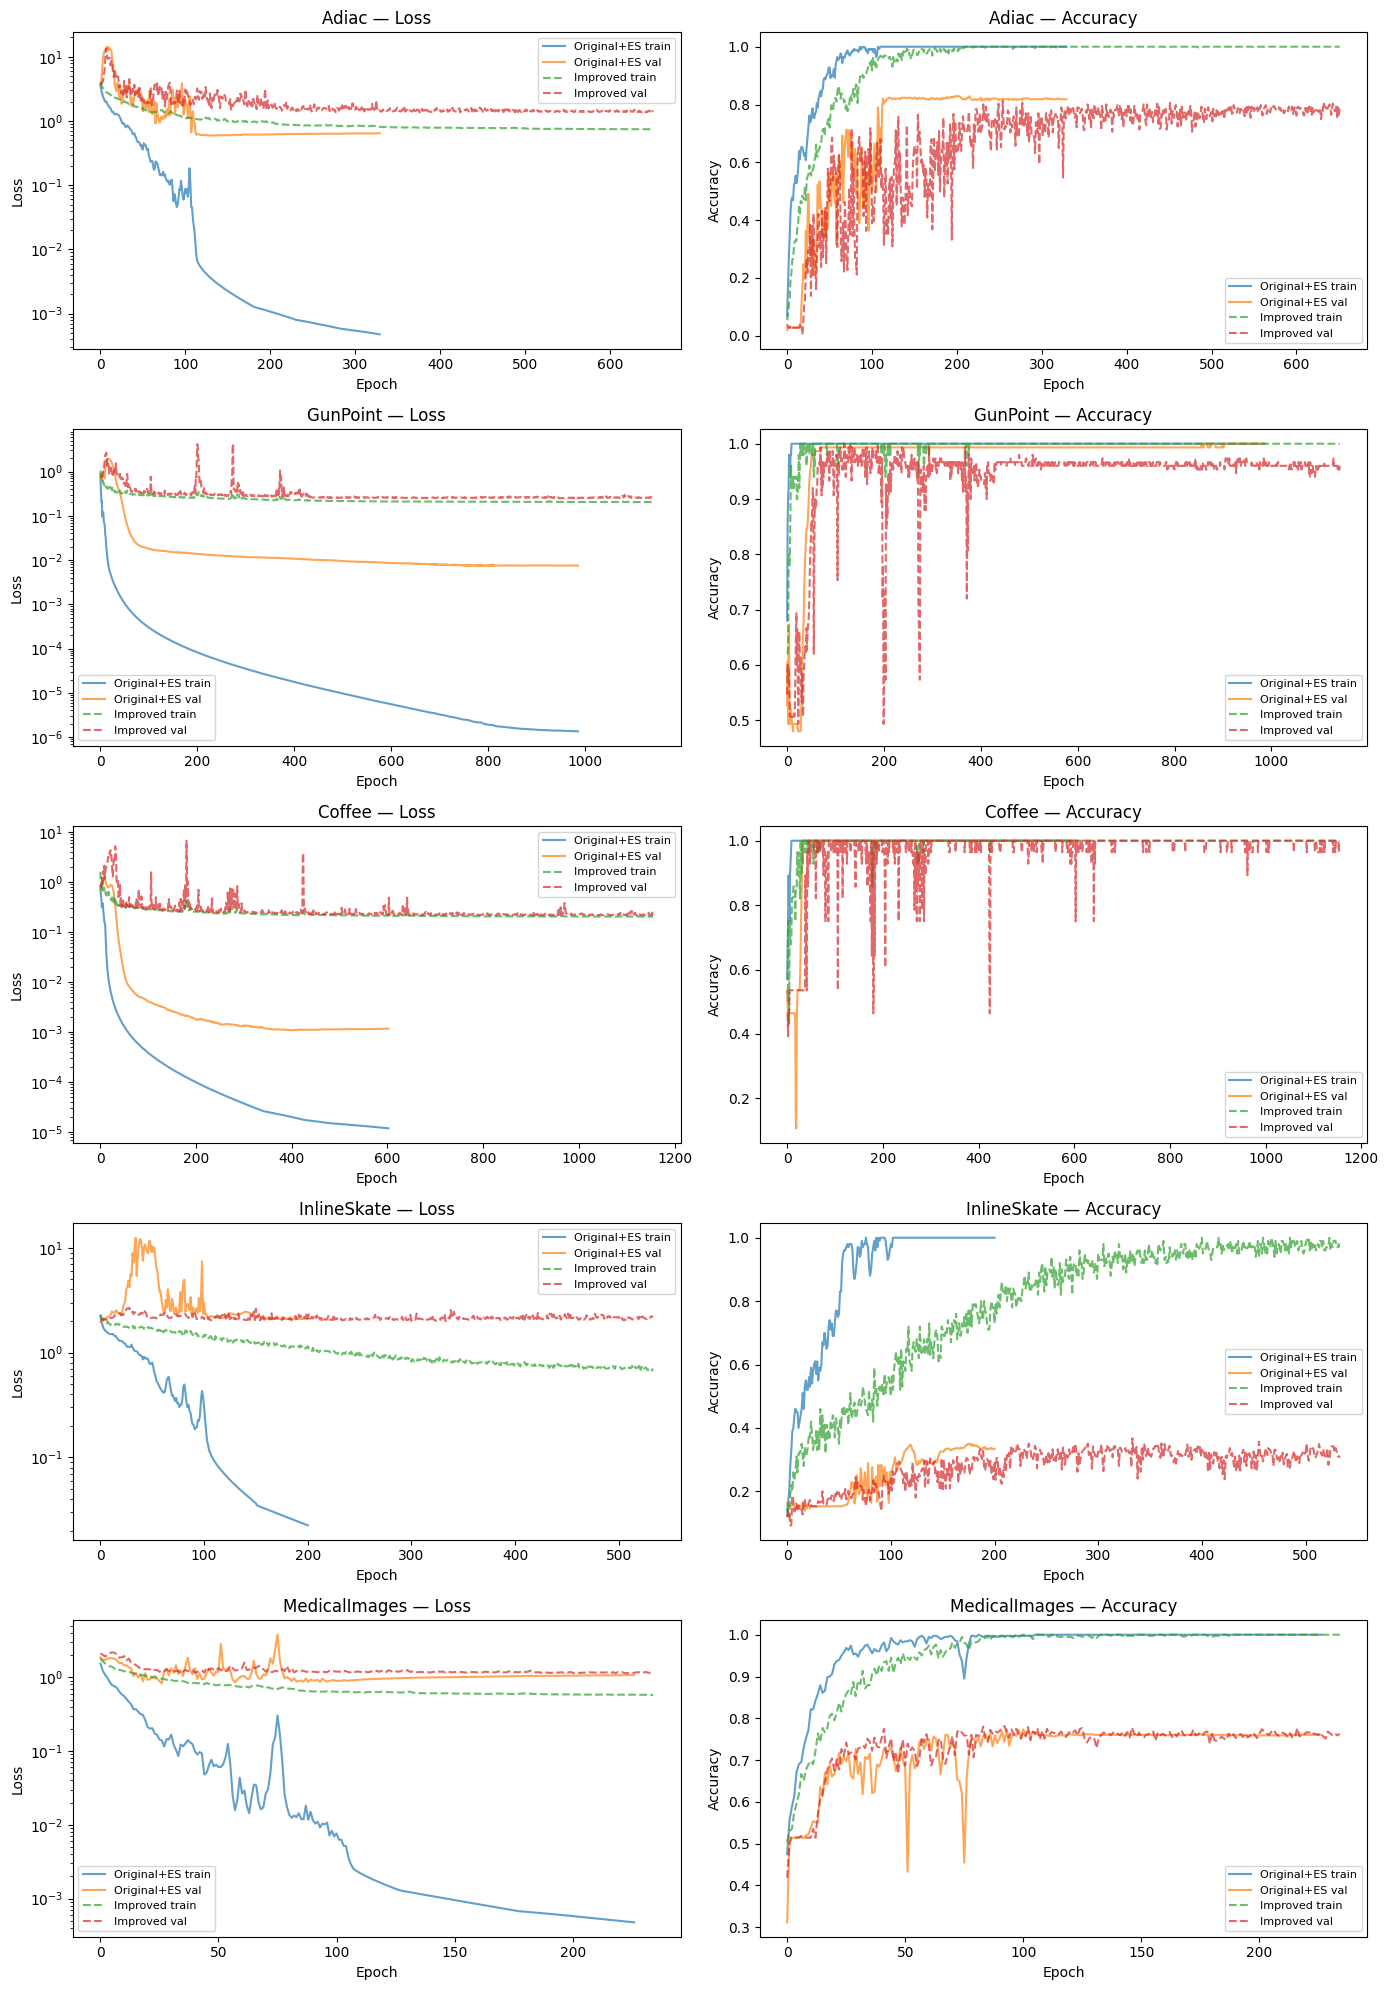

In [20]:
# Training curves
fig, axes = plt.subplots(len(CONFIG['datasets']), 2,
                         figsize=(14, 4 * len(CONFIG['datasets'])))
if len(CONFIG['datasets']) == 1:
    axes = axes.reshape(1, -1)

for row, ds in enumerate(CONFIG['datasets']):
    h_es   = earlystop_results[ds]['all_results'][0]['history']
    h_impr = improved_results[ds]['all_results'][0]['history']

    ax = axes[row, 0]
    ax.plot(h_es['loss'],     label='Original+ES train', alpha=0.7)
    ax.plot(h_es['val_loss'], label='Original+ES val',   alpha=0.7)
    ax.plot(h_impr['loss'],     label='Improved train', alpha=0.7, ls='--')
    ax.plot(h_impr['val_loss'], label='Improved val',   alpha=0.7, ls='--')
    ax.set_title(f'{ds} — Loss')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_yscale('log'); ax.legend(fontsize=8)

    ax = axes[row, 1]
    ax.plot(h_es['accuracy'],     label='Original+ES train', alpha=0.7)
    ax.plot(h_es['val_accuracy'], label='Original+ES val',   alpha=0.7)
    ax.plot(h_impr['accuracy'],     label='Improved train', alpha=0.7, ls='--')
    ax.plot(h_impr['val_accuracy'], label='Improved val',   alpha=0.7, ls='--')
    ax.set_title(f'{ds} — Accuracy')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'resnet_training_curves.png'), dpi=150)
plt.show()

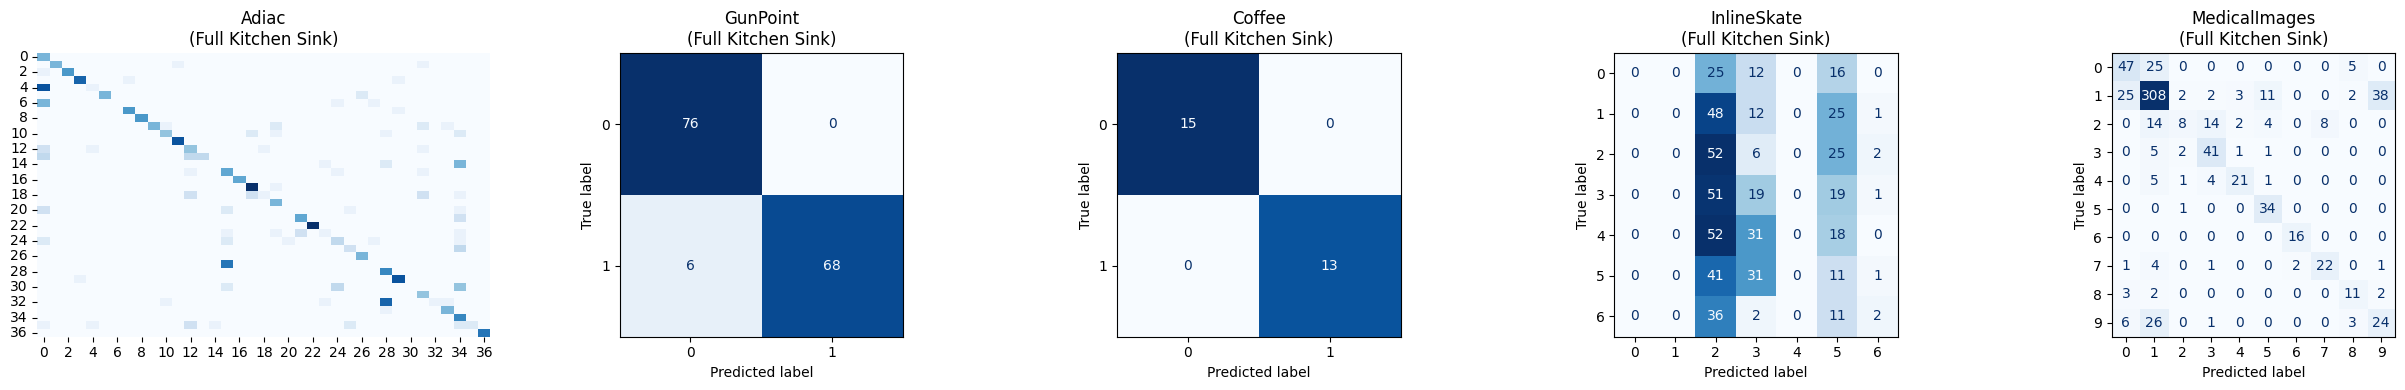

In [21]:
# Confusion matrices
n_ds = len(CONFIG['datasets'])
fig, axes = plt.subplots(1, n_ds, figsize=(5 * n_ds, 4))
if n_ds == 1: axes = [axes]
for i, ds in enumerate(CONFIG['datasets']):
    best_run = kitchen_sink_results[ds]['all_results'][0]
    cm = confusion_matrix(best_run['y_test'], best_run['y_pred'])
    nb_classes = data_store[ds]['nb_classes']
    if nb_classes > 10:
        sns.heatmap(cm, ax=axes[i], cmap='Blues', cbar=False)
    else:
        disp = ConfusionMatrixDisplay(cm)
        disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{ds}\n(Full Kitchen Sink)')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'resnet_confusion_matrices.png'), dpi=150)
plt.show()

In [ ]:
# Bar chart
datasets = CONFIG['datasets']
x_pos = np.arange(len(datasets))
variant_names = [k for k in all_experiments if k != 'Paper']
n_bars = len(variant_names) + 1
width = 0.8 / n_bars

fig, ax = plt.subplots(figsize=(14, 5))

# Paper reference
ax.bar(x_pos - width * len(variant_names)/2,
       [all_experiments['Paper'][ds]['mean_error'] for ds in datasets],
       width, label='Paper', color='#9E9E9E')

colours = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
for j, vn in enumerate(variant_names):
    ax.bar(x_pos - width * len(variant_names)/2 + width * (j+1),
           [all_experiments[vn][ds]['mean_best_val_error'] for ds in datasets],
           width, label=vn, color=colours[j % len(colours)],
           yerr=[all_experiments[vn][ds]['std_best_val_error'] for ds in datasets],
           capsize=3)

ax.set_xlabel('Dataset'); ax.set_ylabel('Error Rate (best val_accuracy)')
ax.set_title('Error Rate Comparison (best val_accuracy — comparable to paper)')
ax.set_xticks(x_pos)
ax.set_xticklabels(datasets, rotation=30, ha='right')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'resnet_barchart.png'), dpi=150)
plt.show()

### Per-Class Metrics, MPCE & Save

In [22]:
# Classification reports
for ds in CONFIG['datasets']:
    best_run = kitchen_sink_results[ds]['all_results'][0]
    print(f"\n{'='*60}")
    print(f"  Classification Report: {ds} (Full Kitchen Sink)")
    print(f"{'='*60}")
    print(classification_report(
        best_run['y_test'], best_run['y_pred'],
        digits=3, zero_division=0
    ))


  Classification Report: Adiac (Full Kitchen Sink)
              precision    recall  f1-score   support

           0      0.171     1.000     0.292         7
           1      1.000     0.778     0.875         9
           2      1.000     0.900     0.947        10
           3      0.923     0.857     0.889        14
           4      0.333     0.071     0.118        14
           5      1.000     0.778     0.875         9
           6      0.000     0.000     0.000         9
           7      0.900     0.900     0.900        10
           8      1.000     1.000     1.000         9
           9      1.000     0.538     0.700        13
          10      0.750     0.500     0.600        12
          11      0.929     1.000     0.963        13
          12      0.353     0.500     0.414        12
          13      1.000     0.333     0.500        12
          14      0.000     0.000     0.000        10
          15      0.308     0.727     0.432        11
          16      1.000     1

In [23]:
# MPCE (paper Equation 4)
def compute_mpce(results_dict, key='mean_error'):
    pce = []
    for ds in CONFIG['datasets']:
        error = results_dict[ds][key]
        pce.append(error / data_store[ds]['nb_classes'])
    return np.mean(pce)

mpce_paper = np.mean([PAPER_RESNET_ERRORS[ds] / data_store[ds]['nb_classes']
                      for ds in CONFIG['datasets']])

print("Mean Per-Class Error (MPCE) — lower is better\n")
print(f"  Paper (published)         : {mpce_paper:.5f}")
for vn in [k for k in all_experiments if k != 'Paper']:
    mpce_r = compute_mpce(all_experiments[vn], 'mean_error')
    mpce_b = compute_mpce(all_experiments[vn], 'mean_best_val_error')
    print(f"  {vn:25s}: {mpce_r:.5f} (restored)  {mpce_b:.5f} (best val_acc)")

Mean Per-Class Error (MPCE) — lower is better

  Paper (published)         : 0.02434
  + EarlySt                : 0.03077 (restored)  0.02473 (best val_acc)
  Improved                 : 0.02662 (restored)  0.02403 (best val_acc)
  Impr+Preproc             : 0.02937 (restored)  0.02540 (best val_acc)
  Full Kitchen Sink        : 0.03368 (restored)  0.02949 (best val_acc)


In [24]:
# Save results
rows = []
for ds in CONFIG['datasets']:
    row = {
        'Dataset': ds,
        'Classes': data_store[ds]['nb_classes'],
        'Train_N': data_store[ds]['x_train'].shape[0],
        'Test_N': data_store[ds]['x_test'].shape[0],
        'Length': data_store[ds]['x_train'].shape[1],
        'Paper_Error': PAPER_RESNET_ERRORS.get(ds, None),
    }
    for en, ed in all_experiments.items():
        if en == 'Paper': continue
        safe = en.replace('+', '').replace(' ', '_').strip('_')
        row[f'{safe}_Error'] = ed[ds]['mean_error']
        row[f'{safe}_Std']   = ed[ds]['std_error']
        row[f'{safe}_BestValErr'] = ed[ds]['mean_best_val_error']
    rows.append(row)

df = pd.DataFrame(rows)
csv_path = os.path.join(CONFIG['output_dir'], 'resnet_results.csv')
df.to_csv(csv_path, index=False)
print(f"Results saved to {csv_path}\n")
df_d = df.copy()
df_d[df_d.select_dtypes('float').columns] = df_d.select_dtypes('float').round(4)
print(df_d.set_index('Dataset').T.to_string())

Results saved to results/resnet_results.csv

Dataset                          Adiac  GunPoint  Coffee  InlineSkate  MedicalImages
Classes                        37.0000    2.0000     2.0       7.0000        10.0000
Train_N                       390.0000   50.0000    28.0     100.0000       381.0000
Test_N                        391.0000  150.0000    28.0     550.0000       760.0000
Length                        176.0000  150.0000   286.0    1882.0000        99.0000
Paper_Error                     0.1740    0.0070     0.0       0.6350         0.2280
EarlySt_Error                   0.2012    0.0044     0.0       0.8364         0.2671
EarlySt_Std                     0.0201    0.0031     0.0       0.0000         0.0121
EarlySt_BestValErr              0.1841    0.0022     0.0       0.6630         0.2285
Improved_Error                  0.1884    0.0133     0.0       0.6745         0.2500
Improved_Std                    0.0053    0.0144     0.0       0.0328         0.0060
Improved_BestValErr 

In [26]:
# Save all ResNet results to Google Drive and download locally

from google.colab import drive
drive.mount('/content/drive')

drive_dir = '/content/drive/MyDrive/TSC_Results/ResNet'
os.makedirs(drive_dir, exist_ok=True)

# Copy results/ to Drive
import shutil
local_results = CONFIG['output_dir']

for fname in os.listdir(local_results):
    src = os.path.join(local_results, fname)
    dst = os.path.join(drive_dir, fname)
    shutil.copy2(src, dst)
    print(f"  → Drive: {dst}")

# Save full results as pickle
import pickle

save_data = {
    'earlystop_results': earlystop_results,
    'improved_results': improved_results,
    'improved_preproc_results': improved_preproc_results,
    'kitchen_sink_results': kitchen_sink_results,
    'all_experiments': all_experiments,
    'CONFIG': CONFIG,
    'PAPER_RESNET_ERRORS': PAPER_RESNET_ERRORS,
}
pkl_path = os.path.join(drive_dir, 'resnet_all_results.pkl')
with open(pkl_path, 'wb') as f:
    pickle.dump(save_data, f)
print(f"  → Drive: {pkl_path}")

print(f"\nAll files saved to Google Drive: {drive_dir}")

# Download to local machine
from google.colab import files
zip_path = '/content/resnet_results.zip'
shutil.make_archive('/content/resnet_results', 'zip', local_results)
files.download(zip_path)
print("Download started — check your browser's download bar.")

Mounted at /content/drive
  → Drive: /content/drive/MyDrive/TSC_Results/ResNet/resnet_confusion_matrices.png
  → Drive: /content/drive/MyDrive/TSC_Results/ResNet/resnet_results.csv
  → Drive: /content/drive/MyDrive/TSC_Results/ResNet/resnet_training_curves.png
  → Drive: /content/drive/MyDrive/TSC_Results/ResNet/resnet_all_results.pkl

All files saved to Google Drive: /content/drive/MyDrive/TSC_Results/ResNet


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started — check your browser's download bar.


### Summary of Findings

#### Architecture Fixes
- Conv2D→Conv1D rewrite matches the paper's "1-D kernels" description
- Parameterised residual blocks replace 90+ lines of copy-paste
- Removed spurious input BatchNorm not in the paper

#### Improvements Applied
- **Early stopping on val_loss** — critical for ResNet which the paper says overfits easily
- **Multi-seed train/evaluation** - running the process over three seeds
- **SpatialDropout1D** — drops entire feature map channels, appropriate for conv layers
- **L2 regularisation** — continuous weight decay on conv kernels
- **Gradient clipping** — stabilises training on long series (InlineSkate, 1882 timesteps)
- **Label smoothing** — reduces overconfident predictions
- **Class weighting** — addresses MedicalImages imbalance
- **Jitter + scaling augmentation** — input-space regularisation
- **Mixup** — virtual training sample creation via interpolation
- **GPU/MPS auto-detection with mixed precision** — meaningful speedup for conv-heavy ResNet